Figure to plot the LFE locations and the observing stations

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits import basemap
from matplotlib import gridspec

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

In [83]:
# read info and LFE locations
lf=lfeanalysis.lfeanalyse(156,region='Cascadia',catalog='Bostock')
tm,loc,mags,iev=\
  lfeanalysis.read_catalogues.read_bostock_cascadia(data_directory=lf.data_directory)

In [84]:
# LFE locations 
iev,ix=np.unique(iev,axis=0,return_index=True)
flocs=loc[ix]

In [85]:
# stations
fdir='/Users/jessicahawthorne/WRITTEN/LFE_Dilation'
fname='station_lists'
fname=os.path.join(fdir,fname)

ln='kdsl'
stats,fnums,locs=[],[],[]
fl=open(fname,'r')
while len(ln)>1:
    ln=fl.readline()
    vls=ln.split(';')[1:]
    loch=[vl.split(',')[1:3] for vl in vls]
    locs=locs+loch
    vls=[vl.split(',')[0] for vl in vls]
    fh=[vl.split('-')[0] for vl in vls]
    vls=[vl.split('-')[1] for vl in vls]
    stats=stats+vls
    fnums=fnums+fh

stats=np.array(stats)
fnums=np.array(fnums).astype(int)
locs=np.array(locs).astype(float)/111.
locs[:,0]=locs[:,0]*np.cos(np.median(loc[:,1]))

# shift from LFE location
ifnums=np.array([np.argmin(np.abs(iev-fnum)) for fnum in fnums])
slocs=locs[:,0:2]+flocs[ifnums,0:2]

stats,ix=np.unique(stats,return_index=True)
slocs=slocs[ix,:]

for k in range(0,len(stats)):
    print(stats[k],slocs[k,:])

B011 [-124.11827097   48.62223333]
B926 [-123.45179798   48.82017928]
B927 [-123.82628488   49.11490811]
KHVB [-123.60509976   48.54944144]
LZB [-123.57040838   48.58678649]
MGCB [-123.62080344   48.62120901]
PGC [-123.06598616   48.64728919]
SHDB [-123.9382441    48.81848018]
YOUB [-123.63707123   48.93870721]


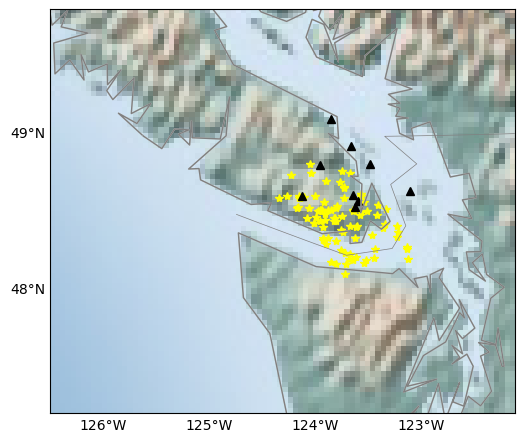

In [89]:
lonlim=[-126.5,-122]
latlim=[47.2,49.8]
lon=np.arange(np.ceil(lonlim[0]),lonlim[1],1)
lat=np.arange(np.ceil(latlim[0]),latlim[1],1)


f=plt.figure(figsize=(6,6))
p=plt.axes()


m = basemap.Basemap(llcrnrlon=lonlim[0],llcrnrlat=latlim[0],urcrnrlon=lonlim[1],
                      urcrnrlat=latlim[1],resolution='l', projection='tmerc', 
                      lat_0 = np.mean(latlim), lon_0 = np.mean(lonlim),
                      suppress_ticks=False)
hlfe=m.plot(flocs[:,0],flocs[:,1], marker='*',linestyle='none',
              latlon=True,color='yellow');
hstat=m.plot(slocs[:,0],slocs[:,1], marker='^',linestyle='none',
              latlon=True,color='black');
m.drawcoastlines(color='lightgray');
m.drawmeridians(lon,labels=[False,False,False,True],linewidth=0.5,zorder=0);
m.drawparallels(lat,labels=[True,False,True,False],linewidth=0.5,zorder=0);
p.set_xticks([]);
p.set_yticks([]);
m.shadedrelief()
m.drawcoastlines(color='gray')
m.drawcountries(color='gray')
m.drawstates(color='gray')
#m.drawlsmask(land_color='coral', ocean_color='skyblue') # Fill ocean with sky blue
